# GeoAtt-PointNet++ — Training (Colab)
Rahmat Zulfikri · Magister Teknik Elektro UGM

Notebook ini untuk training **di Google Colab** menggunakan data dari Google Drive.  
Menggunakan modul proyek yang di-upload ke Drive di `models/`, `utils/`, `losses/`, dan `train.py`.

**Fitur:**
- 🛑 Early Stopping — berhenti otomatis jika val_loss tidak membaik
- 🔧 Two-Phase Training — Phase 1 (main) + Phase 2 (fine-tune LR kecil)
- ⚖️ Dataset Balancing — cap setiap label ke jumlah sesi minimum
- 🔒 Holdout Real Test — 1 sesi per subjek dikecualikan dari training sepenuhnya
- 🔄 Augmentasi — rotasi Z ±90° + tilt X/Y ±15° untuk robustness
- 📊 Live loss plot setelah training selesai

---
### Sections:
1. Setup & Mount Drive
2. Konfigurasi
3. Dataset — Scan, Filter, Balance, Split
4. Training (Fixed Split + Multi-Seed)
5. Plot Loss Curves

## 1. Setup & Cek Environment

In [1]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Install dependencies ───────────────────────────────────────────────────────
!pip install torch torchvision numpy scikit-learn matplotlib pandas tqdm -q

# ── Import standard ───────────────────────────────────────────────────────────
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Root proyek di Google Drive — sesuaikan jika struktur folder berbeda
PROJECT_ROOT = Path('/content/drive/MyDrive/3DCNN')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Import modul proyek ───────────────────────────────────────────────────────
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from torch.utils.data import DataLoader
from tqdm import tqdm

from losses.contrastive import ContrastiveLoss
from losses.triplet import OnlineTripletLoss
from losses.arcface import ArcFaceLoss, HybridArcTripletLoss
from models.siamese import SiamesePalmNet
from train import EarlyStopping, _run_epoch, _run_epoch_triplet, _run_epoch_arcface, _run_epoch_hybrid, _save_checkpoint
from utils.augmentation import PointCloudAugmentor, GeometryAugmentor
from utils.dataset import (
    PalmPairDataset,
    PalmFrameDataset,
    balance_label_frames,
    load_geometry,
    scan_dataset_frames,
    split_holdout_sessions,
    split_sessions_three_way,
)
from utils.normalizer import GeometryNormalizer

warnings.filterwarnings('ignore')

# ── Cek device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'Project : {PROJECT_ROOT}')

# ── Optimisasi GPU (A100-ready) ────────────────────────────────────────────────
# TF32 mempercepat matmul/conv di Ampere (A100) tanpa kehilangan akurasi berarti.
# Aman dinyalakan default — V100 fallback otomatis ke FP32.
if device.type == 'cuda':
    torch.backends.cudnn.benchmark        = True
    torch.backends.cuda.matmul.allow_tf32 = True   # A100: TF32 untuk matmul
    torch.backends.cudnn.allow_tf32       = True   # A100: TF32 untuk cuDNN
    print('cudnn.benchmark + TF32 : aktif')




# ── Auto-detect GPU VRAM / RAM → BATCH_SIZE / NUM_WORKERS / N_POINTS / COMPILE ─
def _auto_config():
    """
    Deteksi GPU memory, CPU cores, dan system RAM → return config optimal.
    """
    import os, subprocess
    # CPU cores
    try:
        n_cpu = os.cpu_count() or 2
    except Exception:
        n_cpu = 2
    # System RAM (GB)
    try:
        with open('/proc/meminfo') as f:
            for line in f:
                if line.startswith('MemTotal:'):
                    sys_ram_gb = int(line.split()[1]) / (1024 ** 2)
                    break
            else:
                sys_ram_gb = 16
    except Exception:
        sys_ram_gb = 16
    # GPU VRAM (MB)
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.total', '--format=csv,noheader,nounits'],
            text=True
        )
        vram_mb = int(out.strip().split('\n')[0])
    except Exception:
        vram_mb = 0
    vram_gb = vram_mb / 1024

    # Heuristic config
    if vram_gb >= 75:          # A100 80GB / H100
        bs, nw, lr, flr = 512, min(8, n_cpu), 2e-3, 2e-4
        n_pts = 8192           # VRAM besar → bisa 2x point density
        use_c = True           # torch.compile worth it di A100
        label = 'A100/H100 class'
    elif vram_gb >= 35:        # A100 40GB
        bs, nw, lr, flr = 384, min(8, n_cpu), 2e-3, 2e-4
        n_pts = 8192
        use_c = True
        label = 'A100 40GB'
    elif vram_mb > 0:          # T4 / L4 / V100 16-24GB
        bs, nw, lr, flr = 128, min(2, n_cpu), 1e-3, 1e-4
        n_pts = 4096
        use_c = False
        label = 'T4/L4/V100 class'
    else:                      # CPU
        bs, nw, lr, flr = 32, 0, 1e-3, 1e-4
        n_pts = 2048
        use_c = False
        label = 'CPU'

    # Preload augment: worth it kalau RAM besar (hemat CPU, percepat training)
    # Estimasi RAM per item: N_POINTS × 6 dim × 4 byte ≈ N_POINTS × 24 byte
    # 1100 frame × repeat(20) × 8192 × 24 B ≈ 4.3 GB — masih sangat aman
    preload = (sys_ram_gb >= 32) and (vram_gb >= 16)

    # FRAME_REPEAT: lebih tinggi kalau RAM besar & preload aktif
    # Dengan preload, repeat tinggi nggak lambatin training (sudah di-RAM)
    if preload and sys_ram_gb >= 128:
        repeat = 30
    elif preload and sys_ram_gb >= 64:
        repeat = 20
    else:
        repeat = 10

    print(f'GPU detect : {label} | VRAM={vram_gb:.1f}GB | CPU={n_cpu} core | RAM={sys_ram_gb:.1f}GB')
    print(f'Auto-config: BATCH_SIZE={bs}, NUM_WORKERS={nw}, N_POINTS={n_pts}, FRAME_REPEAT={repeat}')
    print(f'             LR={lr}, FINETUNE_LR={flr}, torch.compile={use_c}')
    print(f'Preload augment: {preload}')
    return bs, nw, lr, flr, n_pts, use_c, preload, repeat


_AUTO_BS, _AUTO_NW, _AUTO_LR, _AUTO_FLR, _AUTO_N_PTS, _AUTO_COMPILE, _AUTO_PRELOAD, _AUTO_REPEAT = _auto_config()



# ── AMP scaler (digunakan di train_fold untuk mixed precision) ────────────────
_amp_scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
print(f'AMP (mixed prec.) : {"aktif" if _amp_scaler else "nonaktif (CPU)"}')


Mounted at /content/drive
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
Project : /content/drive/MyDrive/3DCNN
cudnn.benchmark + TF32 : aktif
GPU detect : A100/H100 class | VRAM=95.6GB | CPU=48 core | RAM=176.9GB
Auto-config: BATCH_SIZE=512, NUM_WORKERS=8, N_POINTS=8192, FRAME_REPEAT=30
             LR=0.002, FINETUNE_LR=0.0002, torch.compile=True
Preload augment: True
AMP (mixed prec.) : aktif


## 2. Konfigurasi

Ubah parameter di sini sesuai kebutuhan. Semua path bersifat **relatif** terhadap folder proyek.

In [2]:
# ── Timestamp eksekusi ────────────────────────────────────────────────────────from datetime import datetimeimport jsonimport randomEXPERIMENT_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')# ── Path ──────────────────────────────────────────────────────────────────────DATA_DIR   = PROJECT_ROOT / 'dataset'# ── Output dir berdasar varian ───────────────────────────────────────────────if USE_GAM and USE_GEOM_FUSION:    _VARIANT = 'with_geom'elif USE_GAM and not USE_GEOM_FUSION:    _VARIANT = 'gam_only'elif not USE_GAM and USE_GEOM_FUSION:    _VARIANT = 'fuse_only'else:    _VARIANT = 'no_geom'OUTPUT_DIR = PROJECT_ROOT / 'runs' / _VARIANT / EXPERIMENT_TIMESTAMP# ── Dataset ───────────────────────────────────────────────────────────────────BALANCE_DATASET  = TrueHOLDOUT_SESSIONS = 1   # sesi per subjek untuk real test (tidak masuk training)HOLDOUT_FRAMES   = 3   # frame acak dari sesi holdout sebagai probe real test# ── Split training (session-level) ────────────────────────────────────────────# 14 sesi per subjek → ~10 train, ~2 val, ~2 testTRAIN_RATIO = 0.70VAL_RATIO   = 0.15# test_ratio = 0.15 otomatis# Seed untuk pembagian data — satu nilai tetap, dipakai di semua run dan# kedua varian (with_geom / no_geom) agar split identik → paired comparison valid.SPLIT_SEED = 42# ── Multi-seed (untuk uji signifikansi statistik) ─────────────────────────────# Daftar seed untuk stokastik training: bobot awal model, urutan augmentasi,# urutan shuffle DataLoader. Setiap nilai melatih model independen.# Kurangi ke [42] untuk single-run smoke test.SEEDS = [42, 123, 2026, 7, 31337]# ── Model ─────────────────────────────────────────────────────────────────────# 4 varian fair ablation (v0.4.0):#   no_geom    : USE_GAM=False, USE_GEOM_FUSION=False#   gam_only   : USE_GAM=True,  USE_GEOM_FUSION=False#   fuse_only  : USE_GAM=False, USE_GEOM_FUSION=True#   with_geom  : USE_GAM=True,  USE_GEOM_FUSION=True  (shortcut: USE_GEOM=True)USE_GAM          = True   # aktifkan Geometric Attention Module (GAM1/GAM2)USE_GEOM_FUSION  = True   # aktifkan concat geom_emb ke fusion headUSE_GEOM         = True   # shortcut: kalau True → keduanya aktif (backward-compat)GEOM_DIM  = 14N_POINTS  = _AUTO_N_PTS  # auto-detect (T4=4096, A100=8192)SAMPLING  = 'random'  # 'random' atau 'fps'# ── Augmentasi ────────────────────────────────────────────────────────────────LARGE_ROTATION_PROB = 0.3   # P(rotasi Z ±90°) — simulasi tangan diputar saat scanTILT_PROB           = 0.5   # P(X-tilt) dan P(Y-tilt), independen — tangan miringTRANSLATE_PROB      = 0.5   # P(XY translation) — palm tidak tepat di tengah frameTRANSLATE_RANGE     = 0.02  # max XY shift (±2 cm dalam unit cloud yang dinormalisasi)# ── Loss function ─────────────────────────────────────────────────────────────# 'arcface'     → ArcFace (Additive Angular Margin) — supervised, rekomendasi v0.3.0# 'hybrid'      → ArcFace + Triplet hybrid — fine-tuning setelah arcface pretrain# 'triplet'     → OnlineTripletLoss + batch-hard mining (baseline v0.2.0)# 'contrastive' → ContrastiveLoss dengan random pairs (legacy)LOSS_FN        = 'arcface'TRIPLET_MARGIN = 0.3        # margin OnlineTripletLoss (L2 distance scale)ARCFACE_MARGIN = 0.50       # additive angular margin (rad) — ArcFaceARCFACE_SCALE  = 30.0       # scale factor s — ArcFaceNUM_CLASSES    = 11         # jumlah subjek / identitasFRAME_REPEAT   = _AUTO_REPEAT  # auto-detect (T4=10, RAM>=64G=20, >=128G=30)MARGIN         = 0.5        # margin ContrastiveLoss (legacy, dipakai jika LOSS_FN='contrastive')# ── Three-phase training (ArcFace pipeline) ───────────────────────────────────# Phase 1: ArcFace pretrain (supervised classification)# Phase 2: Hybrid ArcFace + Triplet (transition to metric space)# Phase 3: Pure Triplet refinement (metric learning only)PHASE1_EPOCHS = 100PHASE2_EPOCHS = 30PHASE3_EPOCHS = 20# ── Training Phase 1 (Main) ───────────────────────────────────────────────────EPOCHS            = 100BATCH_SIZE        = _AUTO_BS   # auto-detect dari VRAM GPU (T4=128, A100=512)LR                = _AUTO_LR   # auto-detect (T4=1e-3, A100=2e-3)PATIENCE          = 5FINETUNE_PATIENCE = 3MIN_DELTA         = 1e-4NUM_WORKERS       = _AUTO_NW   # auto-detect dari jumlah CPU coreUSE_AMP           = TrueUSE_COMPILE       = _AUTO_COMPILE  # auto-detect (A100=True, T4=False)      # torch.compile — kadang bermasalah dengan custom ops, off default# ── Training Phase 2 (Fine-Tune) ──────────────────────────────────────────────FINETUNE_EPOCHS = 20FINETUNE_LR     = _AUTO_FLR  # auto-detect (T4=1e-4, A100=2e-4)# ── Resume ────────────────────────────────────────────────────────────────────RESUME_FROM = Nonedef set_seed(seed: int) -> None:    """Reset semua RNG sebelum sebuah training run agar bobot awal deterministik."""    random.seed(seed)    np.random.seed(seed)    torch.manual_seed(seed)    if torch.cuda.is_available():        torch.cuda.manual_seed_all(seed)print('Konfigurasi:')print(f'  EXPERIMENT_TIMESTAMP : {EXPERIMENT_TIMESTAMP}')print(f'  DATA_DIR             : {DATA_DIR}')print(f'  OUTPUT_DIR           : {OUTPUT_DIR}')print(f'  USE_GAM              : {USE_GAM}')print(f'  USE_GEOM_FUSION      : {USE_GEOM_FUSION}')print(f'  VARIANT              : {_VARIANT}')print(f'  LOSS_FN              : {LOSS_FN}')if LOSS_FN == 'triplet':    print(f'  TRIPLET_MARGIN       : {TRIPLET_MARGIN}')    print(f'  FRAME_REPEAT         : {FRAME_REPEAT}× per epoch')else:    print(f'  MARGIN (contrastive) : {MARGIN}')print(f'  SPLIT_SEED           : {SPLIT_SEED}  (fixed → split identik antar varian)')print(f'  SEEDS                : {SEEDS}  ({len(SEEDS)} run independen)')print(f'  BALANCE_DATASET      : {BALANCE_DATASET}')print(f'  HOLDOUT_SESSIONS     : {HOLDOUT_SESSIONS}  sesi/subjek dikecualikan')print(f'  HOLDOUT_FRAMES       : {HOLDOUT_FRAMES}  frame probe untuk real test')print(f'  TRAIN_RATIO          : {TRAIN_RATIO}  (~10 sesi/subjek)')print(f'  VAL_RATIO            : {VAL_RATIO}  (~2 sesi/subjek)')print(f'  LARGE_ROTATION_PROB  : {LARGE_ROTATION_PROB}  (P rotasi Z ±90°)')print(f'  TILT_PROB            : {TILT_PROB}  (P tilt X/Y ±15°)')print(f'  TRANSLATE_PROB       : {TRANSLATE_PROB}  (P XY translation)')print(f'  N_POINTS             : {N_POINTS}')print(f'  BATCH_SIZE           : {BATCH_SIZE}')print(f'  NUM_WORKERS          : {NUM_WORKERS}')print(f'  EPOCHS               : {EPOCHS}  (patience={PATIENCE})')print(f'  FINETUNE_EPOCHS      : {FINETUNE_EPOCHS}  (lr={FINETUNE_LR})')if not DATA_DIR.exists():    print(f'  ⚠️  DATA_DIR tidak ditemukan: {DATA_DIR}')    print("     Pastikan dataset sudah di-upload ke Drive.")

Konfigurasi:
  EXPERIMENT_TIMESTAMP : 20260516_210959
  DATA_DIR             : /content/drive/MyDrive/3DCNN/dataset
  OUTPUT_DIR           : /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959
  USE_GEOM             : True
  LOSS_FN              : arcface
  MARGIN (contrastive) : 0.5
  SPLIT_SEED           : 42  (fixed → split identik antar varian)
  SEEDS                : [42, 123, 2026, 7, 31337]  (5 run independen)
  BALANCE_DATASET      : True
  HOLDOUT_SESSIONS     : 1  sesi/subjek dikecualikan
  HOLDOUT_FRAMES       : 3  frame probe untuk real test
  TRAIN_RATIO          : 0.7  (~10 sesi/subjek)
  VAL_RATIO            : 0.15  (~2 sesi/subjek)
  LARGE_ROTATION_PROB  : 0.3  (P rotasi Z ±90°)
  TILT_PROB            : 0.5  (P tilt X/Y ±15°)
  TRANSLATE_PROB       : 0.5  (P XY translation)
  N_POINTS             : 8192
  BATCH_SIZE           : 512
  NUM_WORKERS          : 8
  EPOCHS               : 100  (patience=5)
  FINETUNE_EPOCHS      : 20  (lr=0.0002)


## 3. Dataset — Scan, Filter, Balance, Split

In [3]:
assert DATA_DIR.exists(), f"DATA_DIR tidak ditemukan: {DATA_DIR}"

# ── Scan (filter sesi invalid otomatis) ───────────────────────────────────────
label_frames, session_groups = scan_dataset_frames(DATA_DIR, filter_invalid=True)
print(f'Scan selesai: {len(label_frames)} label')
for label in sorted(session_groups):
    print(f'  {label:<18} {len(session_groups[label])} sesi valid')

# ── Balance ke sesi minimum (SPLIT_SEED agar reproducible) ───────────────────
if BALANCE_DATASET:
    session_groups, min_s = balance_label_frames(session_groups, seed=SPLIT_SEED)
    label_frames = {
        label: [f for ts_frames in ts_dict.values() for f in ts_frames]
        for label, ts_dict in session_groups.items()
    }
    print(f'\n[Balance] Setiap label = {min_s} sesi')

# ── Holdout real test (sebelum split) ─────────────────────────────────────────
# Sesi holdout TIDAK PERNAH masuk training, val, maupun test split.
session_groups, holdout_probes = split_holdout_sessions(
    session_groups,
    n_holdout_sessions=HOLDOUT_SESSIONS,
    n_probe_frames=HOLDOUT_FRAMES,
    seed=SPLIT_SEED,
)
n_holdout_total = sum(len(v) for v in holdout_probes.values())
print(f'[Holdout]  {HOLDOUT_SESSIONS} sesi/subjek → {n_holdout_total} frame probe')

# ── Split sesi sisanya → train/val/test (session-level) ───────────────────────
train_frames, val_frames, test_frames = split_sessions_three_way(
    session_groups, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, seed=SPLIT_SEED
)

# ── Tampilkan distribusi ───────────────────────────────────────────────────────
print(f'\n{"Label":<18} {"Train":>6} {"Val":>6} {"Test":>6} {"Holdout":>8}')
print('─' * 50)
for label in sorted(train_frames):
    n_tr = len(train_frames[label])
    n_va = len(val_frames[label])
    n_te = len(test_frames[label])
    n_ho = len(holdout_probes[label])
    print(f'{label:<18} {n_tr:>6} {n_va:>6} {n_te:>6} {n_ho:>8}')
print('─' * 50)
total_tr = sum(len(v) for v in train_frames.values())
total_va = sum(len(v) for v in val_frames.values())
total_te = sum(len(v) for v in test_frames.values())
print(f'{"TOTAL":<18} {total_tr:>6} {total_va:>6} {total_te:>6} {n_holdout_total:>8}')

assert len(train_frames) >= 2, 'Butuh minimal 2 label untuk membentuk pasangan impostor'

# ── Simpan splits ke JSON untuk evaluate.ipynb ────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
splits_data = {
    'split_seed':    SPLIT_SEED,
    'train_ratio':   TRAIN_RATIO,
    'val_ratio':     VAL_RATIO,
    'holdout_probes': {
        label: [str(f) for f in frames]
        for label, frames in holdout_probes.items()
    },
    'test': {
        label: [str(f) for f in frames]
        for label, frames in test_frames.items()
    },
    'n_train_frames': {label: len(v) for label, v in train_frames.items()},
    'n_val_frames':   {label: len(v) for label, v in val_frames.items()},
    'n_test_frames':  {label: len(v) for label, v in test_frames.items()},
}
with open(OUTPUT_DIR / 'splits.json', 'w') as f:
    json.dump(splits_data, f, indent=2)
print(f'\nsplits.json tersimpan di: {OUTPUT_DIR}')

Scan selesai: 11 label
  aisah              19 sesi valid
  alji               15 sesi valid
  chrys              20 sesi valid
  fadhil             15 sesi valid
  feby               21 sesi valid
  gede               20 sesi valid
  nola               19 sesi valid
  rahmat             15 sesi valid
  reysa              22 sesi valid
  taufik             20 sesi valid
  yanuar             20 sesi valid

[Balance] Setiap label = 15 sesi
[Holdout]  1 sesi/subjek → 33 frame probe

Label               Train    Val   Test  Holdout
──────────────────────────────────────────────────
aisah                  97     20     20        3
alji                  100     20     20        3
chrys                 100     20     20        3
fadhil                100     20     20        3
feby                  100     20     20        3
gede                  100     20     20        3
nola                   91     20     20        3
rahmat                100     20     20        3
reysa                  

## 4. Training

Training menggunakan two-phase approach dengan fixed split dan multi-seed:
- **Phase 1**: Adam + StepLR + Early Stopping
- **Phase 2**: Adam + CosineAnnealingLR + Early Stopping (LR lebih kecil)
- **Multi-seed**: 5 seed independen untuk estimasi mean ± std (uji signifikansi statistik)

Model terbaik (val_loss terendah) disimpan otomatis ke `best.pth`.

In [4]:
def train_fold(train_frames, val_frames, output_dir, scaler=None, seed=None):    """    Training dengan three-phase approach + early stopping.    Phase 1: ArcFace (supervised classification)    Phase 2: Hybrid ArcFace + Triplet    Phase 3: Pure Triplet (metric refinement)    Mengembalikan history loss untuk plotting.    """    output_dir = Path(output_dir)    output_dir.mkdir(parents=True, exist_ok=True)    if seed is not None:        set_seed(seed)    # Fit normalizer pada training frames saja (hindari data leakage)    normalizer = None    if USE_GEOM_FUSION:        all_train_dirs = [f for frames in train_frames.values() for f in frames]        train_geoms    = [load_geometry(d) for d in all_train_dirs]        normalizer     = GeometryNormalizer()        normalizer.fit(train_geoms)        normalizer.save(output_dir / 'normalizer.json')        print(f'Normalizer fitted dari {len(train_geoms)} frame training')    # Augmentor agresif (v0.3.0)    pc_augmentor   = PointCloudAugmentor(        large_rotation_prob=LARGE_ROTATION_PROB,        tilt_prob=TILT_PROB,        translate_prob=TRANSLATE_PROB,        translate_range=TRANSLATE_RANGE,    )    geom_augmentor = GeometryAugmentor(noise_sigma=0.02) if USE_GEOM_FUSION else None    # Dataset (selalu PalmFrameDataset untuk ArcFace / Triplet)    train_ds = PalmFrameDataset(        label_sessions=train_frames, n_points=N_POINTS,        sampling=SAMPLING, augment=pc_augmentor,        geom_augment=geom_augmentor, normalizer=normalizer,        repeat=_AUTO_REPEAT,        preload_augment=_AUTO_PRELOAD)    val_ds = PalmFrameDataset(        label_sessions=val_frames, n_points=N_POINTS,        sampling=SAMPLING, augment=None,        geom_augment=None, normalizer=normalizer,        repeat=1,        preload_augment=False)    train_loader = DataLoader(        train_ds, batch_size=BATCH_SIZE, shuffle=True,        num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),        drop_last=True)    val_loader = DataLoader(        val_ds, batch_size=BATCH_SIZE, shuffle=False,        num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))    # Model dengan ArcFace head jika diperlukan    num_classes = NUM_CLASSES if LOSS_FN in ('arcface', 'hybrid') else 0    model = SiamesePalmNet(        geom_dim=GEOM_DIM,        use_geom=USE_GEOM,        use_gam=USE_GAM,        use_geom_fusion=USE_GEOM_FUSION,        num_classes=num_classes,        arc_margin=ARCFACE_MARGIN,        arc_scale=ARCFACE_SCALE,    ).to(device)    # Compile model (A100)    if USE_COMPILE and device.type == 'cuda':        try:            model = torch.compile(model)            print('[torch.compile] Aktif')        except Exception:            print('[torch.compile] Gagal, fallback ke mode normal')    # ── Phase 1: ArcFace Pretraining ─────────────────────────────────────────    history = {'phase': [], 'epoch': [], 'train_loss': [], 'val_loss': [], 'lr': []}    best_val_loss = float('inf')    if LOSS_FN in ('arcface', 'hybrid'):        print(f'\n=== Phase 1: ArcFace Pretrain (lr={LR:.2e}, max {PHASE1_EPOCHS} epoch) ===')        criterion = ArcFaceLoss(            num_classes=NUM_CLASSES,            margin=ARCFACE_MARGIN,            scale=ARCFACE_SCALE,        )        optimizer = Adam(model.parameters(), lr=LR)        scheduler = StepLR(optimizer, step_size=30, gamma=0.5)        early_stop = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)        for epoch in range(1, PHASE1_EPOCHS + 1):            t0 = time.time()            tl, ta = _run_epoch_arcface(                model, train_loader, criterion, optimizer, device,                train=True, desc=f'P1 ArcFace E{epoch}')            vl, va = _run_epoch_arcface(                model, val_loader, criterion, None, device,                train=False, desc=f'P1 ArcFace Val E{epoch}')            scheduler.step()            lr = scheduler.get_last_lr()[0]            history['phase'].append(1)            history['epoch'].append(epoch)            history['train_loss'].append(tl)            history['val_loss'].append(vl)            history['lr'].append(lr)            print(f'P1 E{epoch:03d}/{PHASE1_EPOCHS}  train={tl:.4f}({ta:.3f})  '                  f'val={vl:.4f}({va:.3f})  lr={lr:.2e}  t={time.time()-t0:.1f}s')            is_best = vl < best_val_loss            if is_best:                best_val_loss = vl                _save_checkpoint(output_dir, model, optimizer, epoch, best_val_loss, 0, 'best.pth')            if early_stop.step(vl, model, epoch):                print(f'  [EarlyStopping] Phase 1 berhenti di epoch {epoch}')                break        # Restore best Phase 1        if early_stop.best_state is not None:            state = {k: v.to(device) for k, v in early_stop.best_state.items()}            model.load_state_dict(state)            print(f'  [EarlyStopping] Best Phase 1 restored (val_loss={best_val_loss:.4f})')    # ── Phase 2: Hybrid ArcFace + Triplet ────────────────────────────────────    if LOSS_FN == 'hybrid' and PHASE2_EPOCHS > 0:        print(f'\n=== Phase 2: Hybrid ArcFace+Triplet (lr={FINETUNE_LR:.2e}, max {PHASE2_EPOCHS} epoch) ===')        criterion = HybridArcTripletLoss(            num_classes=NUM_CLASSES,            arc_margin=ARCFACE_MARGIN,            arc_scale=ARCFACE_SCALE,            triplet_margin=TRIPLET_MARGIN,            arc_weight=0.7,            triplet_weight=0.3,        )        optimizer = Adam(model.parameters(), lr=FINETUNE_LR)        scheduler = CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6)        early_stop = EarlyStopping(patience=FINETUNE_PATIENCE, min_delta=MIN_DELTA)        ft_best = best_val_loss        for epoch in range(1, PHASE2_EPOCHS + 1):            t0 = time.time()            tl = _run_epoch_hybrid(                model, train_loader, criterion, optimizer, device,                train=True, desc=f'P2 Hybrid E{epoch}')            vl = _run_epoch_hybrid(                model, val_loader, criterion, None, device,                train=False, desc=f'P2 Hybrid Val E{epoch}')            scheduler.step()            lr = scheduler.get_last_lr()[0]            history['phase'].append(2)            history['epoch'].append(epoch)            history['train_loss'].append(tl)            history['val_loss'].append(vl)            history['lr'].append(lr)            print(f'P2 E{epoch:03d}/{PHASE2_EPOCHS}  train={tl:.4f}  '                  f'val={vl:.4f}  lr={lr:.2e}  t={time.time()-t0:.1f}s')            is_best = vl < ft_best            if is_best:                ft_best = vl                best_val_loss = ft_best                _save_checkpoint(output_dir, model, optimizer, epoch, best_val_loss, 0, 'best.pth')            if early_stop.step(vl, model, epoch):                print(f'  [EarlyStopping] Phase 2 berhenti di epoch {epoch}')                break        if early_stop.best_state is not None:            state = {k: v.to(device) for k, v in early_stop.best_state.items()}            model.load_state_dict(state)    # ── Phase 3: Pure Triplet (Metric Refinement) ────────────────────────────    if LOSS_FN in ('triplet', 'hybrid') and PHASE3_EPOCHS > 0:        print(f'\n=== Phase 3: Pure Triplet Refinement (lr={FINETUNE_LR:.2e}, max {PHASE3_EPOCHS} epoch) ===')        criterion = OnlineTripletLoss(margin=TRIPLET_MARGIN, mining='batch_hard')        optimizer = Adam(model.parameters(), lr=FINETUNE_LR)        scheduler = CosineAnnealingLR(optimizer, T_max=PHASE3_EPOCHS, eta_min=1e-6)        early_stop = EarlyStopping(patience=FINETUNE_PATIENCE, min_delta=MIN_DELTA)        ft_best = best_val_loss        for epoch in range(1, PHASE3_EPOCHS + 1):            t0 = time.time()            tl = _run_epoch_triplet(                model, train_loader, criterion, optimizer, device,                train=True, desc=f'P3 Triplet E{epoch}')            vl = _run_epoch_triplet(                model, val_loader, criterion, None, device,                train=False, desc=f'P3 Triplet Val E{epoch}')            scheduler.step()            lr = scheduler.get_last_lr()[0]            history['phase'].append(3)            history['epoch'].append(epoch)            history['train_loss'].append(tl)            history['val_loss'].append(vl)            history['lr'].append(lr)            print(f'P3 E{epoch:03d}/{PHASE3_EPOCHS}  train={tl:.4f}  '                  f'val={vl:.4f}  lr={lr:.2e}  t={time.time()-t0:.1f}s')            is_best = vl < ft_best            if is_best:                ft_best = vl                best_val_loss = ft_best                _save_checkpoint(output_dir, model, optimizer, epoch, best_val_loss, 0, 'best.pth')            if early_stop.step(vl, model, epoch):                print(f'  [EarlyStopping] Phase 3 berhenti di epoch {epoch}')                break        if early_stop.best_state is not None:            state = {k: v.to(device) for k, v in early_stop.best_state.items()}            model.load_state_dict(state)    # Simpan final checkpoint    _save_checkpoint(output_dir, model, optimizer, 0, best_val_loss, 0, 'final.pth')    print(f'\nTraining selesai. Best val_loss = {best_val_loss:.4f}')    return history, best_val_loss

In [5]:
# ── Jalankan training (multi-seed) ────────────────────────────────────────────OUTPUT_DIR.mkdir(parents=True, exist_ok=True)# Simpan metadata experimentwith open(OUTPUT_DIR / 'seeds.json', 'w') as f:    json.dump({        'seeds':      SEEDS,        'split_seed': SPLIT_SEED,        'use_geom':   USE_GEOM,        'use_gam':    USE_GAM,        'use_geom_fusion': USE_GEOM_FUSION,        'variant':    _VARIANT,        'timestamp':  EXPERIMENT_TIMESTAMP,        'config': {            'loss_fn':              LOSS_FN,            'phase1_epochs':        PHASE1_EPOCHS,            'phase2_epochs':        PHASE2_EPOCHS,            'phase3_epochs':        PHASE3_EPOCHS,            'batch_size':           BATCH_SIZE,            'num_workers':          NUM_WORKERS,            'lr':                   LR,            'finetune_lr':          FINETUNE_LR,            'triplet_margin':       TRIPLET_MARGIN,            'arcface_margin':       ARCFACE_MARGIN,            'arcface_scale':        ARCFACE_SCALE,            'num_classes':          NUM_CLASSES,            'frame_repeat':         FRAME_REPEAT,            'margin':               MARGIN,            'n_points':             N_POINTS,            'sampling':             SAMPLING,            'balance_dataset':      BALANCE_DATASET,            'train_ratio':          TRAIN_RATIO,            'val_ratio':            VAL_RATIO,            'holdout_sessions':     HOLDOUT_SESSIONS,            'holdout_frames':       HOLDOUT_FRAMES,            'large_rotation_prob':  LARGE_ROTATION_PROB,            'tilt_prob':            TILT_PROB,            'translate_prob':       TRANSLATE_PROB,            'translate_range':      TRANSLATE_RANGE,            'use_compile':          USE_COMPILE,        },    }, f, indent=2)print(f"seeds.json tersimpan di: {OUTPUT_DIR / 'seeds.json'}")all_histories = []   # [(seed, history), ...]all_results   = []   # [{seed, best_val_loss}, ...]t_total = time.time()for seed in SEEDS:    seed_dir = OUTPUT_DIR / f'seed_{seed}'    seed_dir.mkdir(parents=True, exist_ok=True)    print(f'\n{"#"*64}')    print(f'#  SEED {seed}  →  {seed_dir.name}')    print(f'#  Train: {sum(len(v) for v in train_frames.values())} frame  '          f'Val: {sum(len(v) for v in val_frames.values())} frame')    print(f'{"#"*64}')    history, best_loss = train_fold(        train_frames, val_frames, seed_dir,        scaler=_amp_scaler if USE_AMP else None,        seed=seed,    )    all_histories.append((seed, history))    all_results.append({'seed': seed, 'best_val_loss': best_loss})elapsed = time.time() - t_totalprint(f'\n{"="*60}')print(f'Training selesai dalam {elapsed/60:.1f} menit ({len(SEEDS)} seed)')print(f'{"─"*60}')print(f'{"Seed":<10} {"Best Val Loss":>15}')print(f'{"─"*60}')for r in all_results:    print(f'{r["seed"]:<10} {r["best_val_loss"]:>15.4f}')losses = [r['best_val_loss'] for r in all_results]print(f'{"─"*60}')print(f'{"Mean":<10} {sum(losses)/len(losses):>15.4f}')print(f'{"─"*60}')print(f'\nOutput disimpan di: {OUTPUT_DIR}')print(f'Jalankan evaluate.ipynb (USE_GEOM={USE_GEOM}) untuk evaluasi lengkap.')

seeds.json tersimpan di: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/seeds.json

################################################################
#  SEED 42  →  seed_42
#  Train: 1085 frame  Val: 220 frame
################################################################
Normalizer fitted dari 1085 frame training
PalmFrameDataset (PRELOAD): precomputing 32550 augmented variants ...
  Preload selesai: 32550 items, ~6104.9 MB di RAM
PalmFrameDataset: 220 unique frames, 11 labels, repeat=1 → len(dataset)=220
[torch.compile] Aktif

=== Phase 1: ArcFace Pretrain (lr=2.00e-03, max 100 epoch) ===


P1 E001/100  train=2.8075(0.752)  val=0.6989(0.977)  lr=2.00e-03  t=48.5s
    [EarlyStopping] Improved → val_loss=0.6989


P1 E002/100  train=0.0655(0.988)  val=0.5793(0.977)  lr=2.00e-03  t=37.0s
    [EarlyStopping] Improved → val_loss=0.5793


P1 E003/100  train=0.0484(0.992)  val=0.9065(0.959)  lr=2.00e-03  t=37.0s
    [EarlyStopping] No improvement 1/5


P1 E004/100  train=0.0335(0.995)  val=0.7402(0.977)  lr=2.00e-03  t=37.0s
    [EarlyStopping] No improvement 2/5


...

P1 E002/100  train=0.0857(0.986)  val=0.9856(0.968)  lr=2.00e-03  t=37.1s
    [EarlyStopping] No improvement 1/5


P1 E003/100  train=0.0442(0.993)  val=0.8468(0.973)  lr=2.00e-03  t=37.1s
    [EarlyStopping] No improvement 2/5


P1 E004/100  train=0.0388(0.994)  val=0.9717(0.977)  lr=2.00e-03  t=37.1s
    [EarlyStopping] No improvement 3/5


P1 E005/100  train=0.0342(0.995)  val=0.9511(0.977)  lr=2.00e-03  t=37.1s
    [EarlyStopping] No improvement 4/5


P1 E006/100  train=0.0404(0.994)  val=0.9952(0.977)  lr=2.00e-03  t=37.0s
    [EarlyStopping] No improvement 5/5
  [EarlyStopping] Phase 1 berhenti di epoch 6
  [EarlyStopping] Best Phase 1 restored (val_loss=0.7653)

Training selesai. Best val_loss = 0.7653

Training selesai dalam 40.9 menit (5 seed)
────────────────────────────────────────────────────────────
Seed         Best Val Loss
────────────────────────────────────────────────────────────
42                  0.5793
123                 0.4747
2026                0.4594
7                   0.2494
31337               0.7653
────────────────────────────────────────────────────────────
Mean                0.5056
────────────────────────────────────────────────────────────

Output disimpan di: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959
Jalankan evaluate.ipynb (USE_GEOM=True) untuk evaluasi lengkap.


## 5. Plot Loss Curves

Saved: /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/training_curves.png


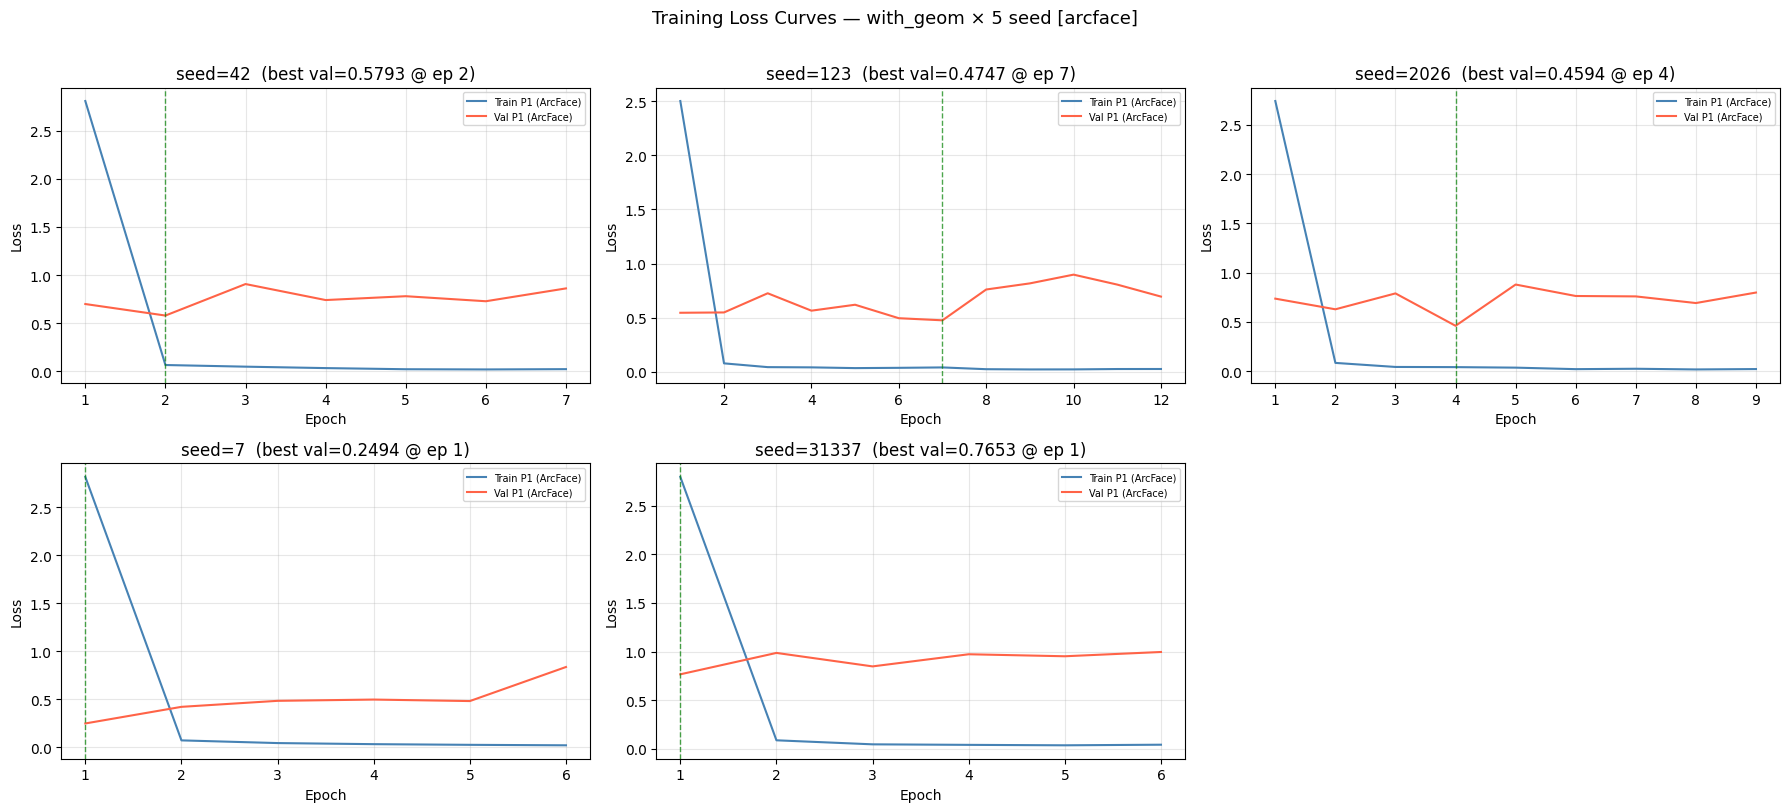

In [6]:
def plot_training_history(histories, save_dir=None):    """    Plot loss curves untuk semua seed.    Phase 1 (ArcFace) = solid blue, Phase 2 (Hybrid) = dashed blue,    Phase 3 (Triplet) = dash-dot blue.    """    n_runs = len(histories)    if n_runs == 0:        print('Tidak ada history untuk diplot.')        return    n_cols  = min(n_runs, 3)    n_rows  = (n_runs + n_cols - 1) // n_cols    fig, axes = plt.subplots(n_rows, n_cols,                             figsize=(6 * n_cols, 4 * n_rows),                             squeeze=False)    for ax_idx, (seed, h) in enumerate(histories):        row, col = divmod(ax_idx, n_cols)        ax = axes[row][col]        phases = np.array(h['phase'])        epochs = np.array(h['epoch'])        tr     = np.array(h['train_loss'])        vl     = np.array(h['val_loss'])        # Build cumulative x-axis        x_all = []        p1_mask = phases == 1        p2_mask = phases == 2        p3_mask = phases == 3        p1_len = p1_mask.sum()        p2_len = p2_mask.sum()        if p1_len > 0:            x_all.extend(epochs[p1_mask].tolist())        if p2_len > 0:            x_all.extend((p1_len + epochs[p2_mask]).tolist())        if p3_mask.sum() > 0:            x_all.extend((p1_len + p2_len + epochs[p3_mask]).tolist())        x_all = np.array(x_all)        tr_all = np.concatenate([tr[p1_mask], tr[p2_mask], tr[p3_mask]]) if any([p1_mask.any(), p2_mask.any(), p3_mask.any()]) else tr        vl_all = np.concatenate([vl[p1_mask], vl[p2_mask], vl[p3_mask]]) if any([p1_mask.any(), p2_mask.any(), p3_mask.any()]) else vl        # Phase 1        if p1_len > 0:            ax.plot(x_all[:p1_len], tr_all[:p1_len],                    color='steelblue', lw=1.5, label='Train P1 (ArcFace)')            ax.plot(x_all[:p1_len], vl_all[:p1_len],                    color='tomato', lw=1.5, label='Val P1 (ArcFace)')        # Phase 2        if p2_len > 0:            ax.plot(x_all[p1_len:p1_len+p2_len], tr_all[p1_len:p1_len+p2_len],                    color='steelblue', lw=1.5, linestyle='--', label='Train P2 (Hybrid)')            ax.plot(x_all[p1_len:p1_len+p2_len], vl_all[p1_len:p1_len+p2_len],                    color='tomato', lw=1.5, linestyle='--', label='Val P2 (Hybrid)')            ax.axvline(p1_len, color='gray', lw=1, linestyle=':')        # Phase 3        if p3_mask.sum() > 0:            p3_start = p1_len + p2_len            ax.plot(x_all[p3_start:], tr_all[p3_start:],                    color='steelblue', lw=1.5, linestyle='-.', label='Train P3 (Triplet)')            ax.plot(x_all[p3_start:], vl_all[p3_start:],                    color='tomato', lw=1.5, linestyle='-.', label='Val P3 (Triplet)')            if p2_len > 0:                ax.axvline(p1_len + p2_len, color='gray', lw=1, linestyle=':')        best_val   = min(vl_all)        best_epoch = x_all[np.argmin(vl_all)]        ax.axvline(best_epoch, color='green', lw=1, linestyle='--', alpha=0.7)        ax.set_xlabel('Epoch')        ax.set_ylabel('Loss')        ax.set_title(f'seed={seed}  (best val={best_val:.4f} @ ep {int(best_epoch)})')        ax.legend(fontsize=7)        ax.grid(True, alpha=0.3)    for ax_idx in range(n_runs, n_rows * n_cols):        row, col = divmod(ax_idx, n_cols)        axes[row][col].set_visible(False)    variant = _VARIANT    plt.suptitle(f'Training Loss Curves — {variant} × {n_runs} seed [{LOSS_FN}]',                 fontsize=13, y=1.01)    plt.tight_layout()    if save_dir:        save_path = Path(save_dir) / 'training_curves.png'        fig.savefig(save_path, dpi=150, bbox_inches='tight')        print(f'Saved: {save_path}')    plt.show()plot_training_history(all_histories, save_dir=OUTPUT_DIR)

In [7]:
# ── Ringkasan hasil training ───────────────────────────────────────────────────
print('Log training tersimpan di:')
for seed, _ in all_histories:
    log_path = OUTPUT_DIR / f'seed_{seed}' / 'train_log.csv'
    if log_path.exists():
        df = pd.read_csv(log_path)
        best_row = df.loc[df['val_loss'].idxmin()]
        print(f'  Seed {seed}: best epoch {int(best_row["epoch"])} '
              f'(phase {int(best_row["phase"])})  '
              f'val_loss={best_row["val_loss"]:.4f}  '
              f'train_loss={best_row["train_loss"]:.4f}')
    else:
        print(f'  Seed {seed}: log tidak ditemukan')

variant = 'with_geom' if USE_GEOM else 'no_geom'
print(f'\nVariant      : {variant}')
print(f'Output dir   : {OUTPUT_DIR}')
print(f'splits.json  : {OUTPUT_DIR / "splits.json"}')
print(f'Holdout probe: {n_holdout_total} frame ({HOLDOUT_SESSIONS} sesi/subjek × {len(train_frames)} subjek)')
print(f'\nLangkah selanjutnya:')
print(f'  1. Jalankan evaluate.ipynb        → evaluasi test set standar')
print(f'  2. Jalankan evaluate.ipynb         → evaluasi real test (holdout probe belum pernah dilihat model)')


Log training tersimpan di:
  Seed 42: log tidak ditemukan
  Seed 123: log tidak ditemukan
  Seed 2026: log tidak ditemukan
  Seed 7: log tidak ditemukan
  Seed 31337: log tidak ditemukan

Variant      : with_geom
Output dir   : /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959
splits.json  : /content/drive/MyDrive/3DCNN/runs/with_geom/20260516_210959/splits.json
Holdout probe: 33 frame (1 sesi/subjek × 11 subjek)

Langkah selanjutnya:
  1. Jalankan evaluate.ipynb        → evaluasi test set standar
  2. Jalankan evaluate.ipynb         → evaluasi real test (holdout probe belum pernah dilihat model)
